C:\Users\Le Li\Anaconda3\lib\site-packages\matplotlib\tight_layout.py:199: UserWarning: Tight layout not applied. tight_layout cannot make axes width small enough to accommodate all axes decorations
  warnings.warn('Tight layout not applied. '
C:\Users\Le Li\Anaconda3\lib\site-packages\matplotlib\tight_layout.py:199: UserWarning: Tight layout not applied. tight_layout cannot make axes width small enough to accommodate all axes decorations
  warnings.warn('Tight layout not applied. '


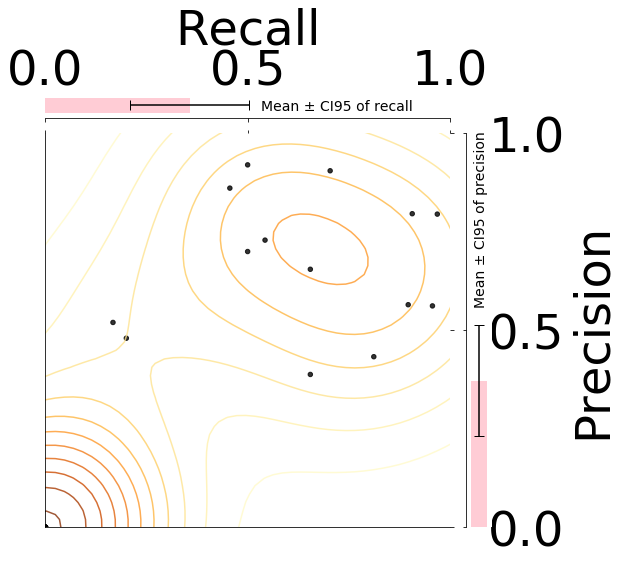

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde
import pandas as pd

font1 = 48
font2 = 28
plt.rcParams.update({'font.size': font1})

# ------------------------------------------------------------------
# Load per-pair precision / recall
# ------------------------------------------------------------------
WKDIR = "FigS2/"
IN_TSV = f"{WKDIR}AFM_interspecies_precision_recall.tsv"
df_pr = pd.read_csv(IN_TSV, sep="\t")

pre_lst = df_pr["Precision"].to_numpy()
rec_lst = df_pr["Recall"].to_numpy()
pair_ids = df_pr["Pair"].tolist()
g = sns.JointGrid(x=rec_lst, y=pre_lst, space=0.6, height=8, ratio=10)

# ------------------------------------------------------------------
# Joint scatter with highlighted pairs
# ------------------------------------------------------------------
sizes = np.full(len(rec_lst), 20.0)
# colors = np.array(['black'] * len(rec_lst), dtype=object)

g.ax_joint.scatter(rec_lst, pre_lst, s=sizes, c='black', alpha=0.8)

# ------------------------------------------------------------------
# Side bars: mean ± CI95, oriented parallel to the sides
# ------------------------------------------------------------------
n = len(rec_lst)

# recall: mean ± 95% CI
mean_rec = rec_lst.mean()
se_rec = rec_lst.std(ddof=1) / np.sqrt(n)
ci95_rec = 1.96 * se_rec

# precision: mean ± 95% CI
mean_pre = pre_lst.mean()
se_pre = pre_lst.std(ddof=1) / np.sqrt(n)
ci95_pre = 1.96 * se_pre

# Top marginal: horizontal bar (parallel to top edge) for recall
ax_mx = g.ax_marg_x
ax_mx.barh(
    [0.5],
    [mean_rec],
    xerr=[ci95_rec],
    height=0.6,
    color="pink",
    alpha=0.8,
    error_kw=dict(capsize=5),
)

ax_mx.set_xlim(0, 1)
ax_mx.set_ylim(0, 1)
ax_mx.set_yticks([])
# ax_mx.set_xlabel('Mean ± CI95 of recall', fontsize=font2 * 0.7)


# Right marginal: vertical bar (parallel to right edge) for precision
ax_my = g.ax_marg_y
ax_my.bar(
    [0.5],
    [mean_pre],
    yerr=[ci95_pre],
    width=0.6,
    color="pink",
    alpha=0.8,
    error_kw=dict(capsize=5),
)
ax_my.set_xlim(0, 1)
ax_my.set_ylim(0, 1)
ax_my.set_xticks([])


# ------------------------------------------------------------------
# KDE contour on the joint panel (unchanged)
# ------------------------------------------------------------------
sns.kdeplot(
    rec_lst,          # x
    pre_lst,          # y
    ax=g.ax_joint,
    cmap='YlOrBr',
    n_levels=15,      # use n_levels in older seaborn
    shade=False,
    alpha=0.8,
)



g.ax_joint.tick_params(axis='x', pad=35)
g.ax_joint.tick_params(axis='y', pad=35)
# put recall label near the top–left, away from "Recall"
g.fig.text(
    0.5, 0.868, "Mean ± CI95 of recall",
    ha="left", va="top", fontsize=font2 * 0.5
)

# put precision label near the lower–right, away from "Precision"
g.fig.text(
    0.894, 0.66, "Mean ± CI95 of precision",
    ha="right", va="center", rotation=90,
    fontsize=font2 * 0.5
)
# Axis labels and ticks (same as your original)
g.ax_joint.xaxis.tick_top()
g.ax_joint.xaxis.set_label_position('top')
g.ax_joint.set_xlabel('Recall')
# g.ax_joint.set_xticks([0, 0.5, 1], [0, 0.5, ''])

g.ax_joint.yaxis.tick_right()
g.ax_joint.yaxis.set_label_position('right')
g.ax_joint.set_ylabel('Precision')
g.ax_joint.set_yticks([0, 0.5, 1])
# g.ax_joint.set_yticklabels([0, 0.5, 1])
plt.tight_layout()
plt.savefig(f'{WKDIR}/FigS2.svg',
            format='svg', bbox_inches='tight')
plt.show()
